# BBB subgroup and matched model comparison

Addresses R1.6, R3.3 and the interpretation of smaller subgroup RMSE.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Define the subgroup

The rule uses MW≤500, 0≤logP≤5, TPSA≤90, HBD≤2 and rotatable bonds≤8. It is a physicochemical rule, not experimental BBB permeability and not the ADMET BBB output. HBA is computed but is not a threshold condition.

In [2]:
d=dataset();rule=(d['MW, g/mol']<=500)&d.logP.between(0,5)&(d.tpsa<=90)&(d.hbd<=2)&(d.rotatable_bonds<=8)
assert np.array_equal(rule.astype(int),d.bbb_rule_pass)
print('Rule reproduces all',len(d),'stored subgroup assignments.')

Rule reproduces all 12584 stored subgroup assignments.


## Evaluate on exactly the same compounds

Compare the specialist with full-training Plain and Baseline on the specialist test IDs. A lower error on a restricted population alone does not establish that specialist training helps.

In [3]:
rows=[]
for seed in range(42,47):
    b=table(f'global_models/seed{seed}/BBB_pass/test_predictions.csv').set_index('ligand_id')
    for name in ['BBB_pass','Plain','Baseline']:
        p=table(f'global_models/seed{seed}/{name}/test_predictions.csv').set_index('ligand_id').loc[b.index]
        assert np.allclose(p.y,b.y)
        rows.append({'seed':seed,'model':name,'n_test':len(p),'rmse':np.sqrt(np.mean((p.y-p.prediction)**2))})
matched=pd.DataFrame(rows);display(matched.groupby('model').rmse.agg(['mean','std']))
original=additional('bbb_same_subset')
assert np.allclose(matched.rmse,original.rmse)

,mean,std
model,,
BBB_pass,0.47591,0.01422
Baseline,0.47672,0.01131
Plain,0.46279,0.00880


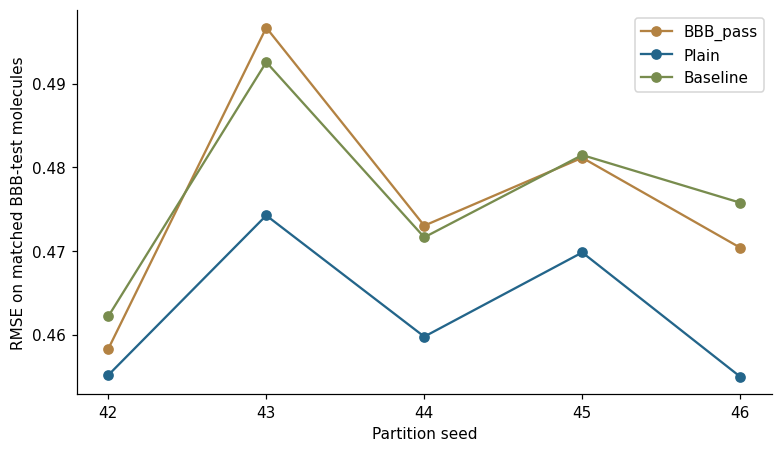

,seed,comparison,mse_delta,ci_low,ci_high
0,42,BBB_minus_Plain,0.00286,-0.00746,0.01506
1,42,BBB_minus_Baseline,-0.00358,-0.01445,0.00814
2,43,BBB_minus_Plain,0.02180,0.01030,0.03386
3,43,BBB_minus_Baseline,0.00408,-0.00608,0.01417
4,44,BBB_minus_Plain,0.01238,0.00154,0.02307
5,44,BBB_minus_Baseline,0.00132,-0.00978,0.01266
6,45,BBB_minus_Plain,0.01077,0.00123,0.02109
7,45,BBB_minus_Baseline,-0.00031,-0.01209,0.01383
8,46,BBB_minus_Plain,0.01427,0.00120,0.02811
9,46,BBB_minus_Baseline,-0.00509,-0.01631,0.00661


In [4]:
fig,ax=plt.subplots(figsize=(7,4),layout='constrained')
for name in ['BBB_pass','Plain','Baseline']:
    g=matched[matched.model.eq(name)]
    ax.plot(g.seed,g.rmse,'o-',label=name,color=COLORS[name])
ax.set(xticks=range(42,47),xlabel='Partition seed',ylabel='RMSE on matched BBB-test molecules');ax.legend();finish(fig,'matched_bbb_comparison')
display(additional('bbb_paired_comparison'))

## Interpretation

Plain outperforms the BBB specialist on the same subgroup in all five partitions. The BBB-domain analysis remains descriptive; it does not establish a benefit from specialist training. The subgroup’s reduced endpoint variability helps explain why RMSE, R² and rank correlation need to be read together.